In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Environmental Dataset

### Data Processing

In [2]:
env_df = pd.read_csv("environmental_dataset.csv")

In [3]:
env_df.head(5)

,SensorID,SensorLocation,Pollutant_PM2.5_µg/m³,Pollutant_PM10_µg/m³,Pollutant_O3_ppb,Pollutant_NO2_ppb,Pollutant_CO_ppm,Pollutant_SO2_ppb,UrbanVegetationArea_m2,Humidity_%,...,EnergySavingTechnology,AnnualEnergySavings_%,PopulationDensity_people/km²,RetrofitData,RenewableEnergyPercentage_%,AnnualEnergyConsumption_kWh,GreenSpaceIndex_%,HistoricPollutantLevels,Country,AQI_Index
0,S000001,Industrial Area,71.990,101.550,183.240,65.92,30.81,33.040,750.58,42.68,...,Solar Panels,5.22,1912.59,Yes,1.16,47054.58,30.69,164.21,Kyrgyzstan,87.92
1,S000002,Industrial Area,69.960,16.710,40.990,123.30,4.12,26.440,982.93,62.27,...,NaN,31.74,1144.57,Yes,44.40,20672.65,5.96,180.58,Yemen,51.54
2,S000003,Rural,78.135,100.404,30.016,55.27,23.65,6.564,8780.38,78.95,...,Efficient HVAC,15.66,NaN,Yes,21.35,49459.50,48.10,290.00,Kyrgyzstan,64.06
3,S000004,Industrial Area,79.640,128.900,29.500,130.68,9.10,28.580,NaN,36.55,...,LED Lighting,29.32,1832.64,Yes,15.75,5953.21,15.77,241.86,Cambodia,77.47
4,S000005,Industrial Area,63.350,296.260,76.560,52.04,29.87,44.110,917.23,41.13,...,Smart Thermostats,16.29,1624.23,Yes,13.81,16232.45,57.01,90.68,Thailand,106.47


In [4]:
env_df.rename(columns = {
    "Pollutant_PM2.5_µg/m³": "PM2.5",
    "Pollutant_PM10_µg/m³": "PM10",
    "Pollutant_O3_ppb": "O3",
    "Pollutant_NO2_ppb": "NO2", 
    "Pollutant_CO_ppm": "CO",
    "Pollutant_SO2_ppb": "SO2",
    "PopulationDensity_people/km²": "PopulationDensity"
}, inplace = True)

##### Handling Missing Values

In [5]:
env_df.isna().sum()

SensorID                          0
SensorLocation                    0
PM2.5                             0
PM10                              0
O3                                0
NO2                               0
CO                                0
SO2                               0
UrbanVegetationArea_m2         2521
Humidity_%                        0
AirTemperature_C                  0
EnergySavingTechnology         1094
AnnualEnergySavings_%             0
PopulationDensity              1024
RetrofitData                      0
RenewableEnergyPercentage_%     749
AnnualEnergyConsumption_kWh       0
GreenSpaceIndex_%                 0
HistoricPollutantLevels           0
Country                           0
AQI_Index                         0
dtype: int64

In [6]:
groupby_country_df = env_df.groupby(by = "Country").agg({
    "UrbanVegetationArea_m2": "median",
    "EnergySavingTechnology": lambda x: x.mode().iloc[0],
    "PopulationDensity": "median",
    "RenewableEnergyPercentage_%": "median"
})

groupby_country_df

,UrbanVegetationArea_m2,EnergySavingTechnology,PopulationDensity,RenewableEnergyPercentage_%
Country,,,,
Afghanistan,1916.230,Solar Panels,1133.140,24.035
Armenia,1710.950,Solar Panels,1180.440,25.915
Azerbaijan,2218.540,Solar Panels,1133.180,23.765
Bangladesh,1724.230,Solar Panels,1200.090,21.280
Bhutan,1991.750,Solar Panels,1321.390,25.740
Brunei,2078.790,Solar Panels,1175.420,26.725
Cambodia,2143.395,Solar Panels,922.750,24.050
China,2080.090,Solar Panels,1305.650,23.810
Georgia,2160.080,Solar Panels,1115.730,26.095


In [7]:
groupby_country_df.reset_index(inplace = True)

In [8]:
env_df = pd.merge(env_df, groupby_country_df, on = "Country", how = "left", suffixes = ["", "_agg"])

In [9]:
columns_to_fill = ["UrbanVegetationArea_m2", "EnergySavingTechnology", "PopulationDensity", "RenewableEnergyPercentage_%"]
for column in columns_to_fill:
    env_df[column].fillna(env_df[f"{column}_agg"], inplace = True)
    env_df.drop(columns = [f"{column}_agg"], inplace = True)

C:\Users\PC\AppData\Local\Temp\ipykernel_19100\2128449075.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  env_df[column].fillna(env_df[f"{column}_agg"], inplace = True)
C:\Users\PC\AppData\Local\Temp\ipykernel_19100\2128449075.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


##### Handling Duplicate Values

In [10]:
env_df.drop(columns = ["SensorID"], inplace = True)

In [11]:
env_df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

In [12]:
def barplot_handler(data, y, x, title, xlabel, ylabel):
    sns.barplot(
        data = data, 
        y = y,
        hue = y, 
        x = x, 
        orient = "h", 
        palette = ["#60a5fa" if i == 0 else "#dbeafe" for i in range(data[data.columns[0]].count())],
        legend = False
    )
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [13]:
def scatterplot_handler(data, y, x, title, xlabel, ylabel):
    sns.scatterplot(
        data = data,
        y = y,
        x = x
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [14]:
def boxplot_handler(data, title):
    plt.figure(figsize = (8, 5))

    sns.boxplot(
        data = data,
    )

    plt.title(title)
    plt.show()

In [29]:
def remove_outliers_handler(data, column):
    if isinstance(data, pd.DataFrame):
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR 
        upper_bound = Q3 + 1.5 * IQR

        data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]   
        return data 
    else:
        return data


#### Annual Energy Savings

##### Energy Saving Technology

In [15]:
groupby_est_df = env_df.groupby(by = "EnergySavingTechnology").agg({
    "AnnualEnergySavings_%": "mean"
}).sort_values(by = "AnnualEnergySavings_%", ascending = False)

groupby_est_df

,AnnualEnergySavings_%
EnergySavingTechnology,
Smart Thermostats,22.598621
Insulation,22.125269
LED Lighting,21.918974
Efficient HVAC,21.867222
Solar Panels,21.421467


In [16]:
groupby_est_df.reset_index(inplace = True)

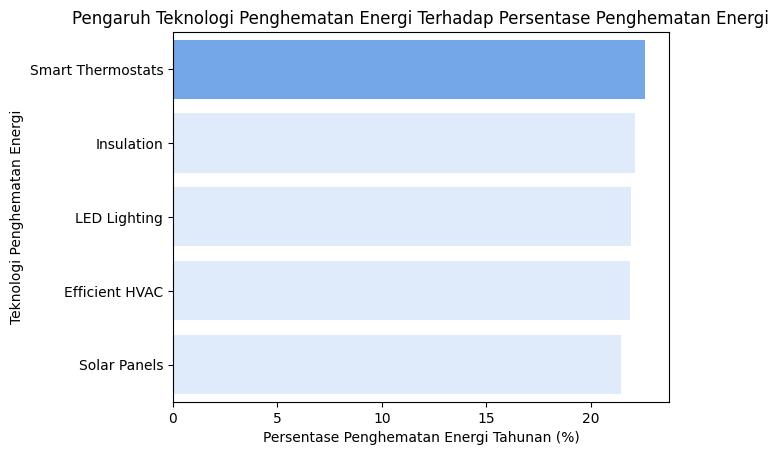

In [17]:
barplot_handler(
    groupby_est_df, 
    "EnergySavingTechnology", 
    "AnnualEnergySavings_%", 
    "Pengaruh Teknologi Penghematan Energi Terhadap Persentase Penghematan Energi", 
    "Persentase Penghematan Energi Tahunan (%)", 
    "Teknologi Penghematan Energi"
)

##### Retrofit

In [18]:
groupby_retrofit_df = env_df.groupby(by = "RetrofitData").agg({
    "AnnualEnergySavings_%": "mean"
}).sort_values(by =  "AnnualEnergySavings_%", ascending = False)

groupby_retrofit_df

,AnnualEnergySavings_%
RetrofitData,
Yes,21.838261
No,21.605977


In [19]:
groupby_retrofit_df.reset_index(inplace = True)

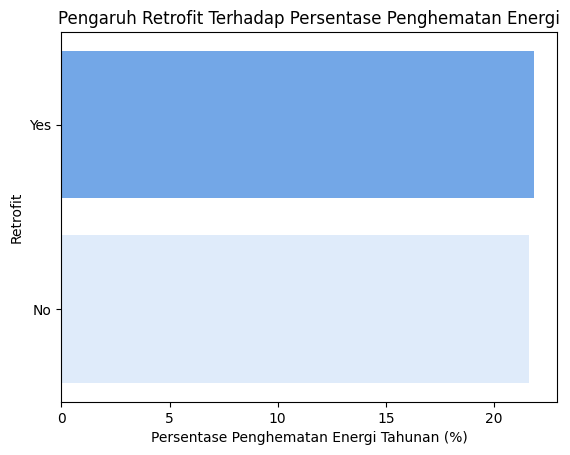

In [20]:
barplot_handler(
    groupby_retrofit_df, 
    "RetrofitData", 
    "AnnualEnergySavings_%", 
    "Pengaruh Retrofit Terhadap Persentase Penghematan Energi", 
    "Persentase Penghematan Energi Tahunan (%)", 
    "Retrofit"
)

##### Urban Vegetation Area

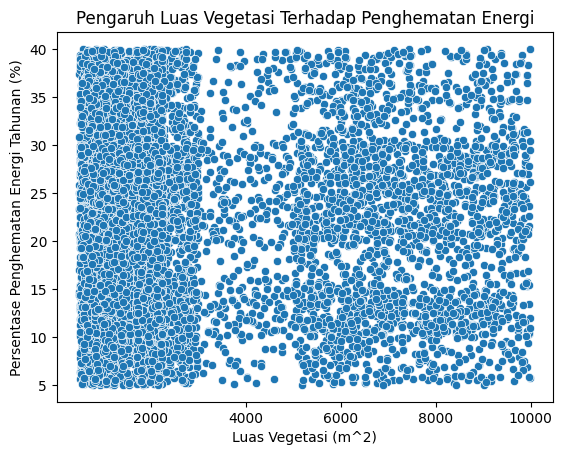

In [21]:
scatterplot_handler(
    env_df,
    "AnnualEnergySavings_%",
    "UrbanVegetationArea_m2",
    "Pengaruh Luas Vegetasi Terhadap Penghematan Energi",
    "Luas Vegetasi (m^2)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Humidity

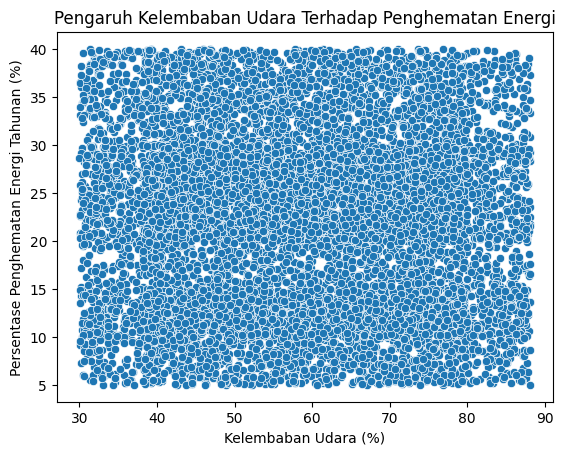

In [22]:
scatterplot_handler(
    env_df,
    "AnnualEnergySavings_%",
    "Humidity_%",
    "Pengaruh Kelembaban Udara Terhadap Penghematan Energi",
    "Kelembaban Udara (%)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Population Density

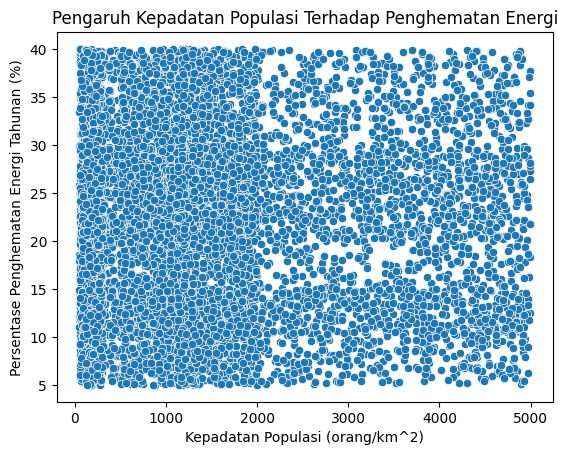

In [23]:
scatterplot_handler(
    env_df,
    "AnnualEnergySavings_%",
    "PopulationDensity",
    "Pengaruh Kepadatan Populasi Terhadap Penghematan Energi",
    "Kepadatan Populasi (orang/km^2)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Renewable Energy Percentage

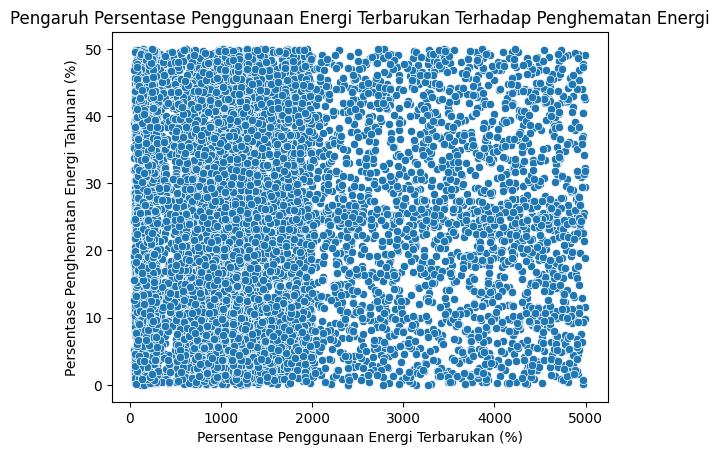

In [24]:
scatterplot_handler(
    env_df,
    "RenewableEnergyPercentage_%",
    "PopulationDensity",
    "Pengaruh Persentase Penggunaan Energi Terbarukan Terhadap Penghematan Energi",
    "Persentase Penggunaan Energi Terbarukan (%)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Annual Energy Consumption

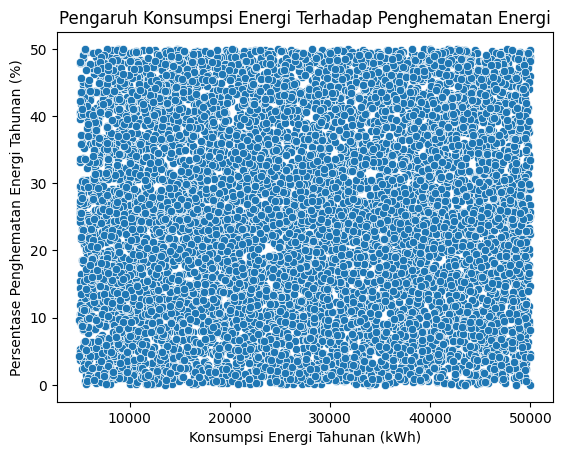

In [25]:
scatterplot_handler(
    env_df,
    "RenewableEnergyPercentage_%",
    "AnnualEnergyConsumption_kWh",
    "Pengaruh Konsumpsi Energi Terhadap Penghematan Energi",
    "Konsumpsi Energi Tahunan (kWh)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Green Space Index

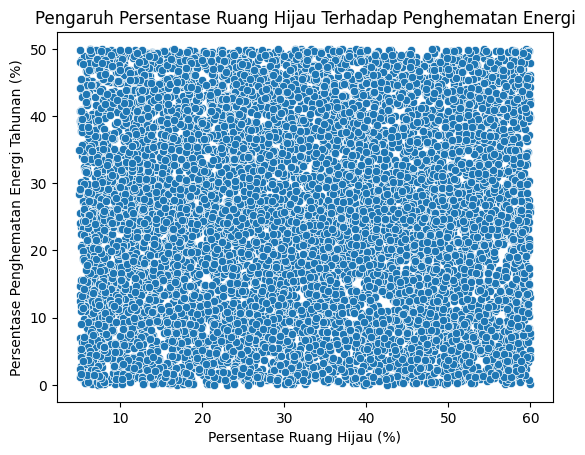

In [26]:
scatterplot_handler(
    env_df,
    "RenewableEnergyPercentage_%",
    "GreenSpaceIndex_%",
    "Pengaruh Persentase Ruang Hijau Terhadap Penghematan Energi",
    "Persentase Ruang Hijau (%)",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Historic Pollutant Levels

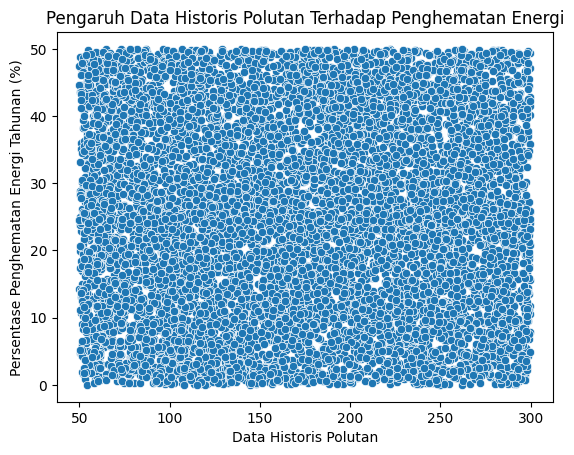

In [27]:
scatterplot_handler(
    env_df,
    "RenewableEnergyPercentage_%",
    "HistoricPollutantLevels",
    "Pengaruh Data Historis Polutan Terhadap Penghematan Energi",
    "Data Historis Polutan",
    "Persentase Penghematan Energi Tahunan (%)"
)

##### Handle Outliers

In [28]:
energy_df = env_df[[
    "UrbanVegetationArea_m2", 
    "Humidity_%", 
    "AirTemperature_C", 
    "EnergySavingTechnology", 
    "PopulationDensity", 
    "RetrofitData",
    "RenewableEnergyPercentage_%",
    "AnnualEnergyConsumption_kWh",
    "GreenSpaceIndex_%",
    "HistoricPollutantLevels",
    "AnnualEnergySavings_%"
]]

In [30]:
energy_df_categorical_columns = ["EnergySavingTechnology", "RetrofitData"]

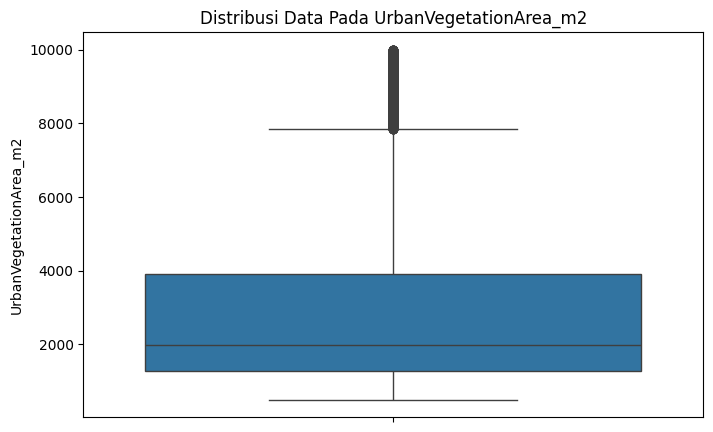

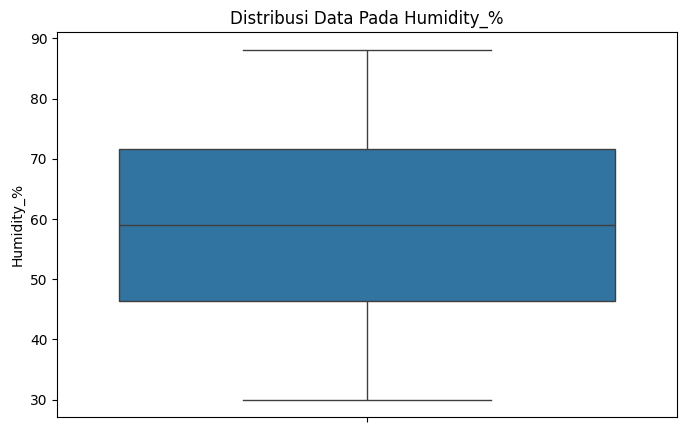

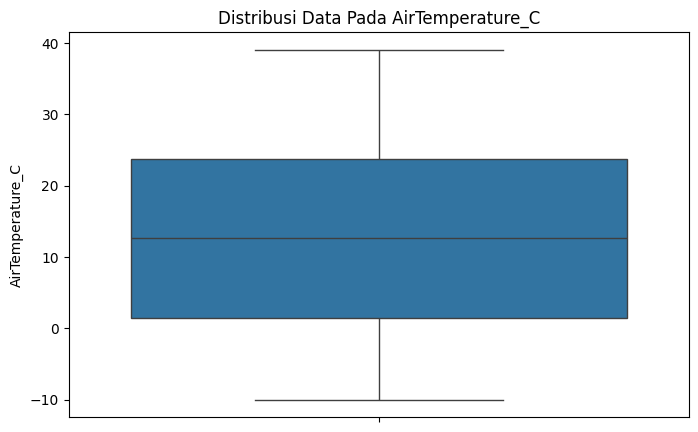

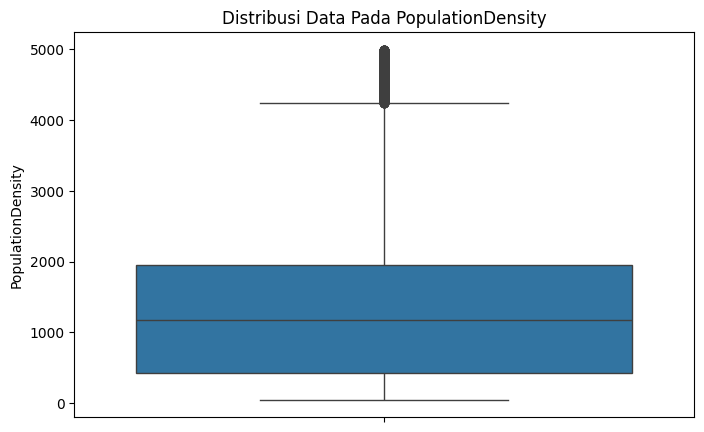

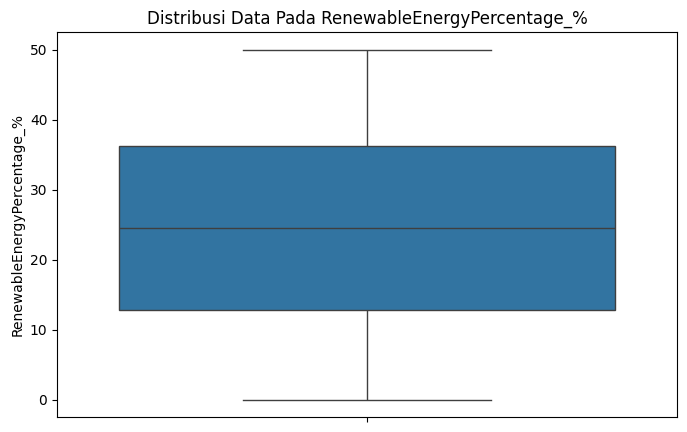

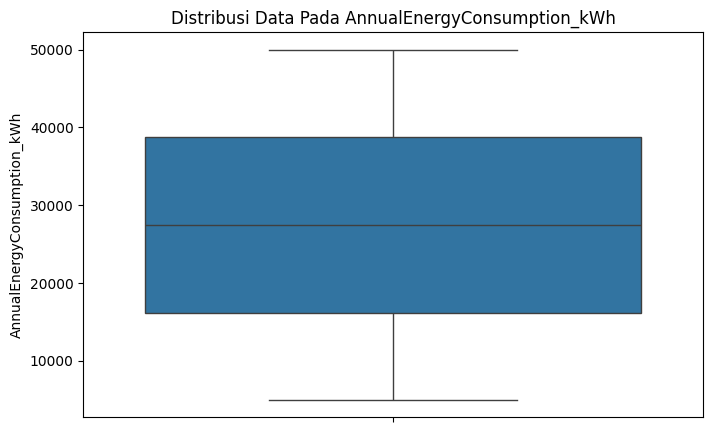

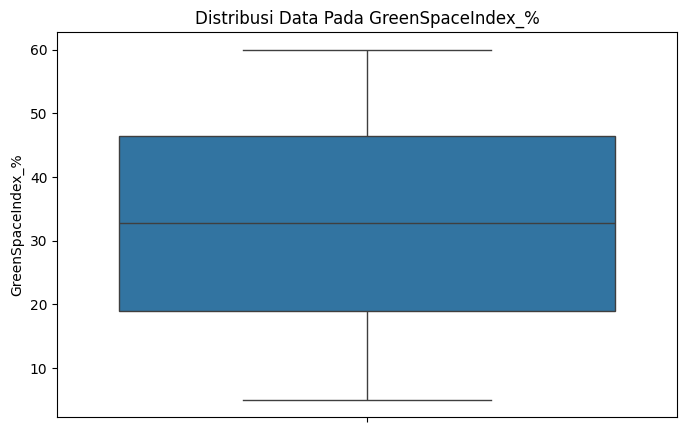

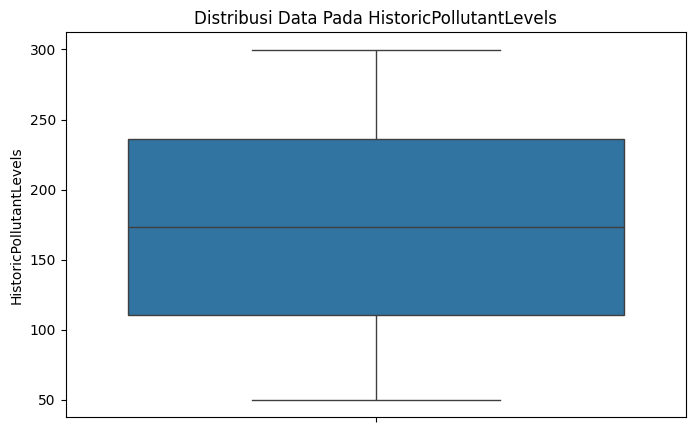

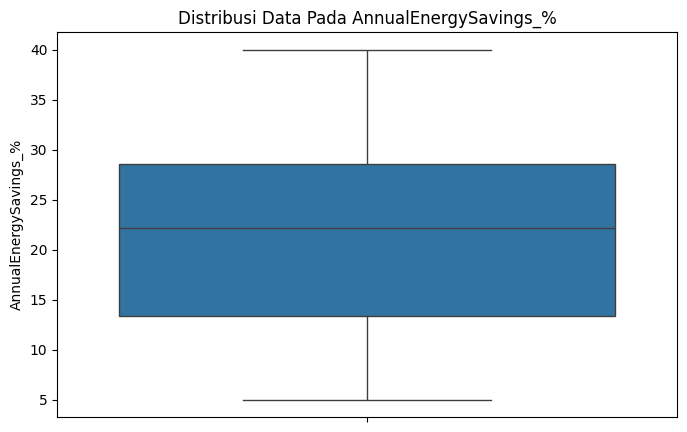

In [31]:
energy_df_numerical_columns = []
for column in energy_df.columns:
    if column not in energy_df_categorical_columns:
        energy_df_numerical_columns.append(column)
        boxplot_handler(energy_df[column], f"Distribusi Data Pada {column}")

In [32]:
energy_df = remove_outliers_handler(energy_df, "UrbanVegetationArea_m2")
energy_df = remove_outliers_handler(energy_df, "PopulationDensity")

##### Feature Importance and Correlation

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [34]:
scaler = StandardScaler()

In [35]:
for column in energy_df_categorical_columns:
    if column in energy_df.columns:
        energy_df[column] = energy_df[column].astype("category").cat.codes

In [36]:
X_edf = energy_df.drop(columns = ["AnnualEnergySavings_%"])
y_edf = energy_df["AnnualEnergySavings_%"]

In [37]:
X_scaled_edf = scaler.fit_transform(X_edf)

In [38]:
rfr = RandomForestRegressor()

In [39]:
rfr.fit(X_scaled_edf, y_edf)

RandomForestRegressor()

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X_edf.columns,
    "Importance": rfr.feature_importances_
}).sort_values(by = "Importance", ascending = False)

feature_importance

,Feature,Importance
6,RenewableEnergyPercentage_%,0.668452
2,AirTemperature_C,0.046771
7,AnnualEnergyConsumption_kWh,0.046353
1,Humidity_%,0.045284
8,GreenSpaceIndex_%,0.044974
9,HistoricPollutantLevels,0.044870
0,UrbanVegetationArea_m2,0.043458
4,PopulationDensity,0.043336
3,EnergySavingTechnology,0.011095
5,RetrofitData,0.005405


In [41]:
energy_df.corr()

,UrbanVegetationArea_m2,Humidity_%,AirTemperature_C,EnergySavingTechnology,PopulationDensity,RetrofitData,RenewableEnergyPercentage_%,AnnualEnergyConsumption_kWh,GreenSpaceIndex_%,HistoricPollutantLevels,AnnualEnergySavings_%
UrbanVegetationArea_m2,1.000000,-0.075030,-0.010882,-0.003344,-0.413931,-0.000069,0.011344,-0.003847,-0.003964,0.003883,0.006815
Humidity_%,-0.075030,1.000000,0.015455,0.008737,0.086331,-0.007050,0.000116,0.002378,0.014035,-0.016693,-0.009055
AirTemperature_C,-0.010882,0.015455,1.000000,-0.002367,0.017963,0.008252,-0.015522,0.016613,0.007619,-0.007989,-0.002526
EnergySavingTechnology,-0.003344,0.008737,-0.002367,1.000000,0.013065,-0.015635,-0.030283,-0.014426,0.001873,-0.002884,-0.018871
PopulationDensity,-0.413931,0.086331,0.017963,0.013065,1.000000,0.008802,-0.000624,0.002865,0.001062,0.003714,-0.004624
RetrofitData,-0.000069,-0.007050,0.008252,-0.015635,0.008802,1.000000,0.007825,-0.010453,-0.001071,-0.017462,0.008663
RenewableEnergyPercentage_%,0.011344,0.000116,-0.015522,-0.030283,-0.000624,0.007825,1.000000,0.014568,0.008062,0.012435,0.729060
AnnualEnergyConsumption_kWh,-0.003847,0.002378,0.016613,-0.014426,0.002865,-0.010453,0.014568,1.000000,0.010065,0.003600,0.023705
GreenSpaceIndex_%,-0.003964,0.014035,0.007619,0.001873,0.001062,-0.001071,0.008062,0.010065,1.000000,0.005819,0.016970
HistoricPollutantLevels,0.003883,-0.016693,-0.007989,-0.002884,0.003714,-0.017462,0.012435,0.003600,0.005819,1.000000,0.005071


#### Air Quality (AQI)

##### Renewable Energy Percentage

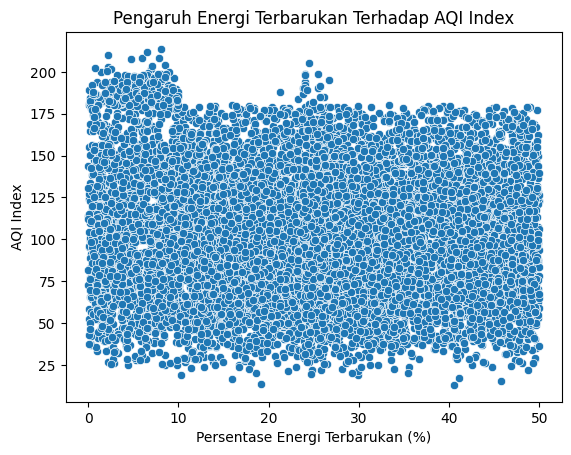

In [43]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "RenewableEnergyPercentage_%",
    "Pengaruh Energi Terbarukan Terhadap AQI Index",
    "Persentase Energi Terbarukan (%)",
    "AQI Index"
)

##### Annual Energy Savings

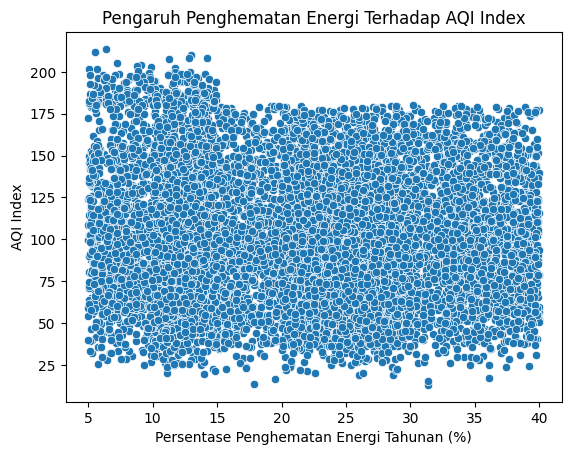

In [44]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "AnnualEnergySavings_%",
    "Pengaruh Penghematan Energi Terhadap AQI Index",
    "Persentase Penghematan Energi Tahunan (%)",
    "AQI Index"
)

##### Annual Energy Consumption

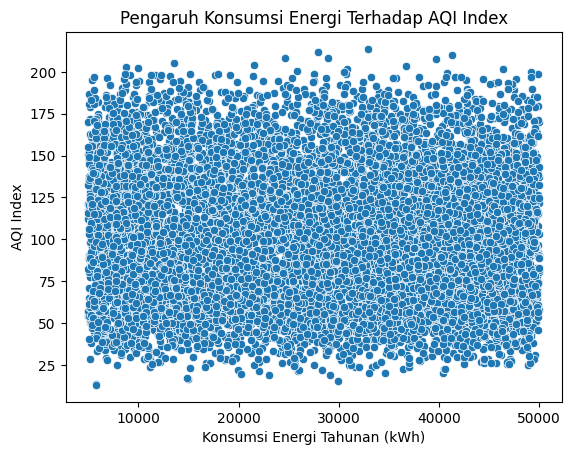

In [51]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "AnnualEnergyConsumption_kWh",
    "Pengaruh Konsumsi Energi Terhadap AQI Index",
    "Konsumsi Energi Tahunan (kWh)",
    "AQI Index"
)

##### Pollutant

PM2.5

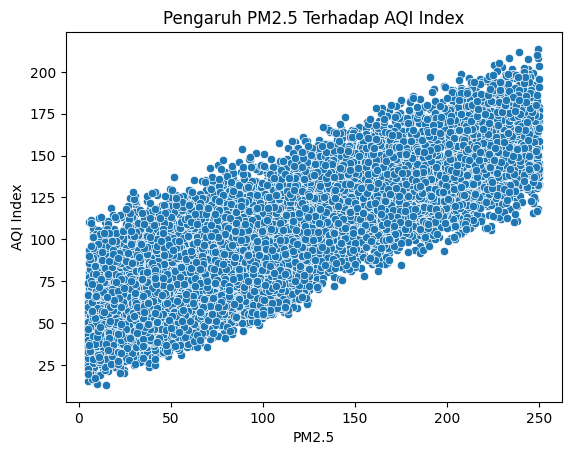

In [45]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "PM2.5",
    "Pengaruh PM2.5 Terhadap AQI Index",
    "PM2.5",
    "AQI Index"
)

PM10

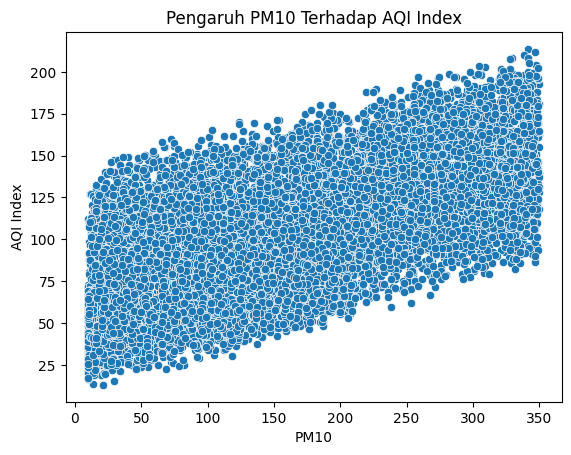

In [46]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "PM10",
    "Pengaruh PM10 Terhadap AQI Index",
    "PM10",
    "AQI Index"
)

O3

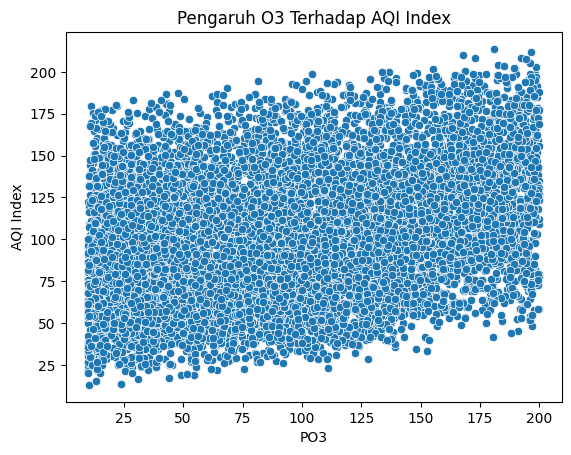

In [47]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "O3",
    "Pengaruh O3 Terhadap AQI Index",
    "PO3",
    "AQI Index"
)

NO2

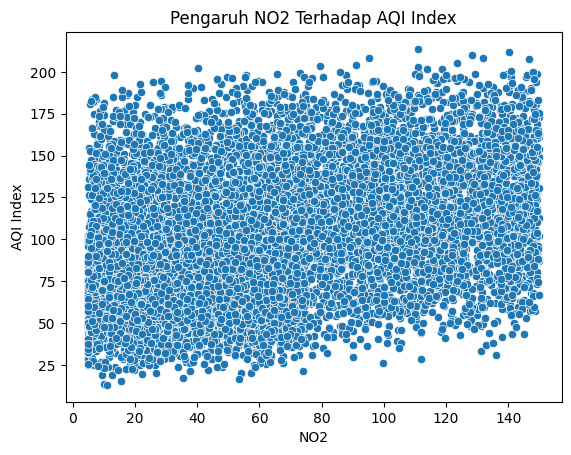

In [48]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "NO2",
    "Pengaruh NO2 Terhadap AQI Index",
    "NO2",
    "AQI Index"
)

CO

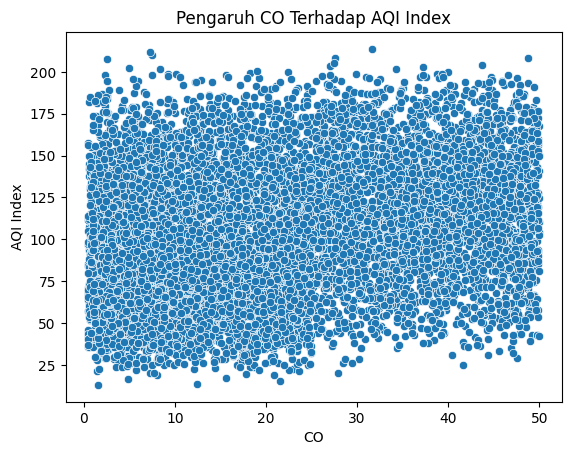

In [49]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "CO",
    "Pengaruh CO Terhadap AQI Index",
    "CO",
    "AQI Index"
)

SO2

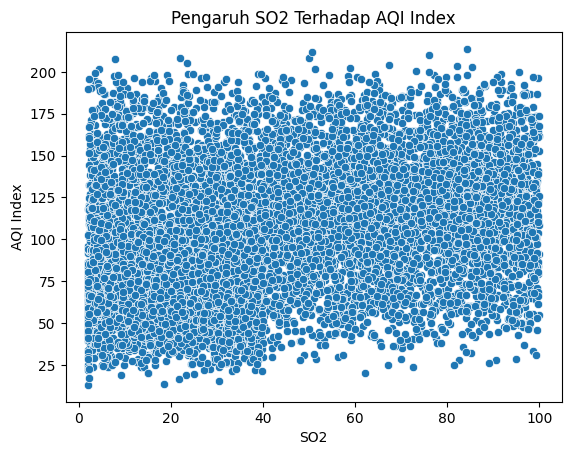

In [50]:
scatterplot_handler(
    env_df,
    "AQI_Index",
    "SO2",
    "Pengaruh SO2 Terhadap AQI Index",
    "SO2",
    "AQI Index"
)

##### Handle Outliers

In [52]:
air_df = env_df[[
    "PM2.5",
    "PM10",
    "O3",
    "NO2",
    "CO",
    "SO2",
    "AnnualEnergySavings_%",
    "AnnualEnergyConsumption_kWh",
    "RenewableEnergyPercentage_%",
    "AQI_Index"
]]

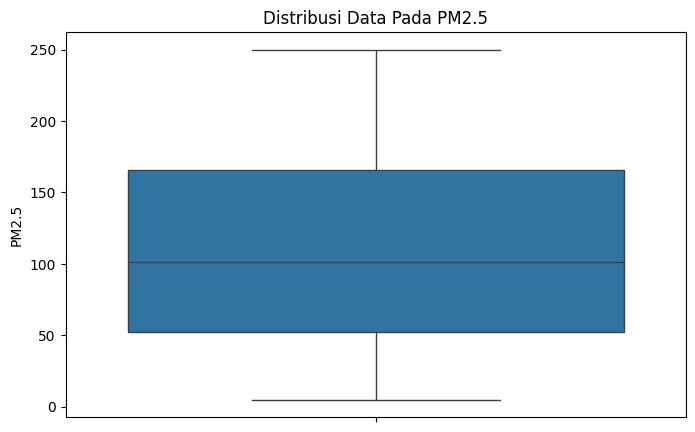

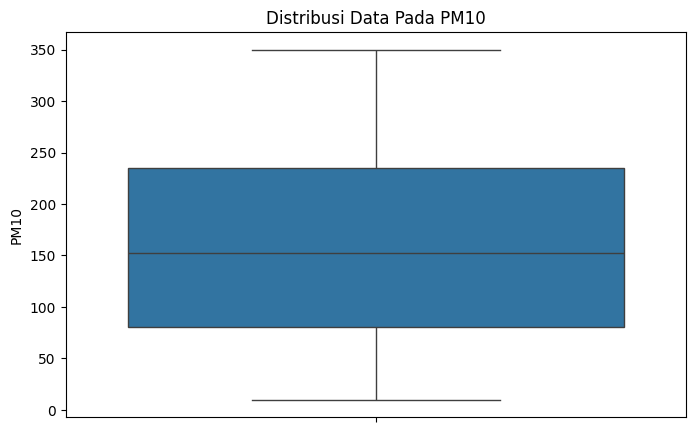

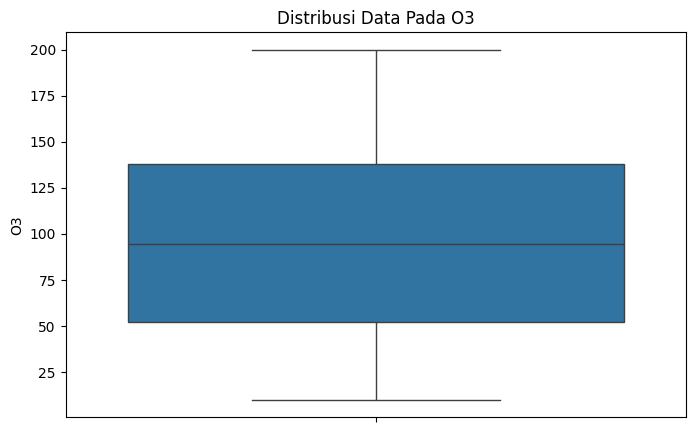

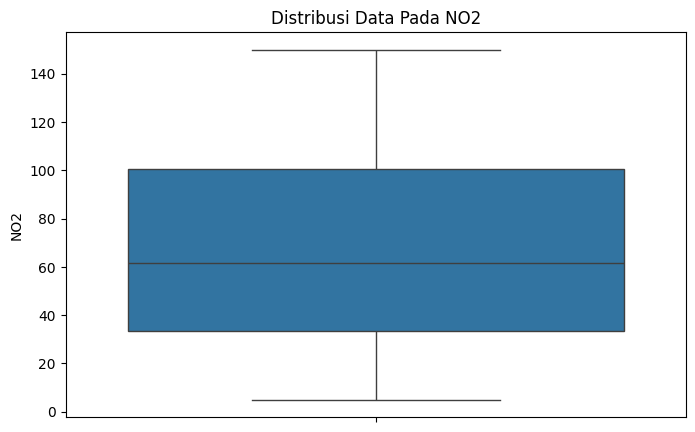

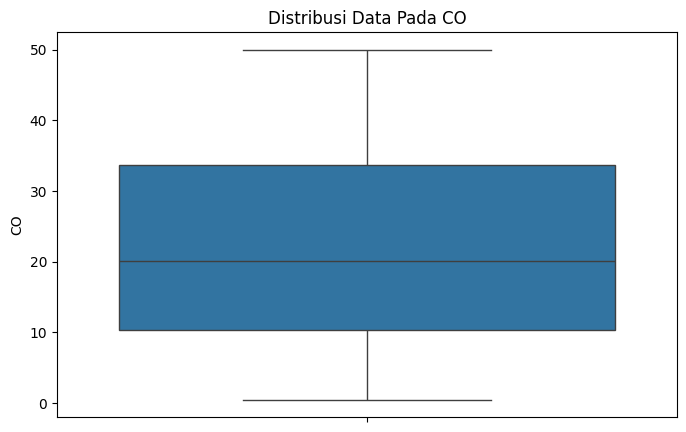

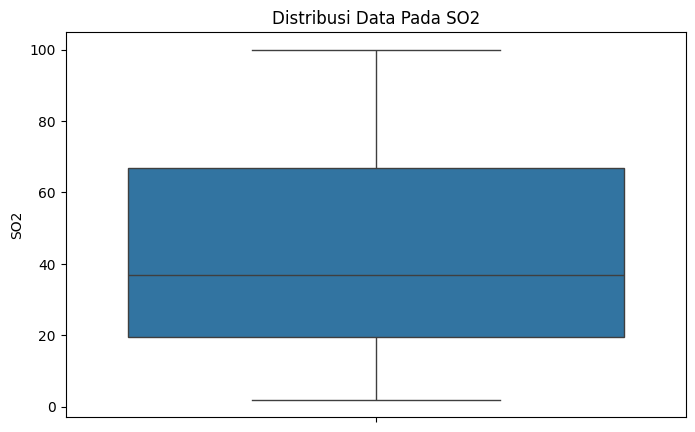

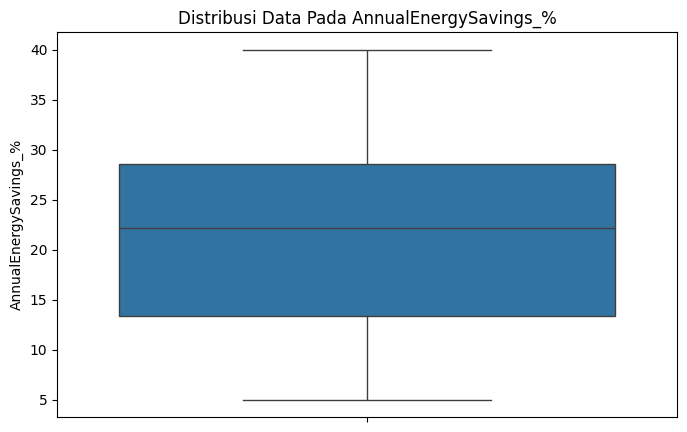

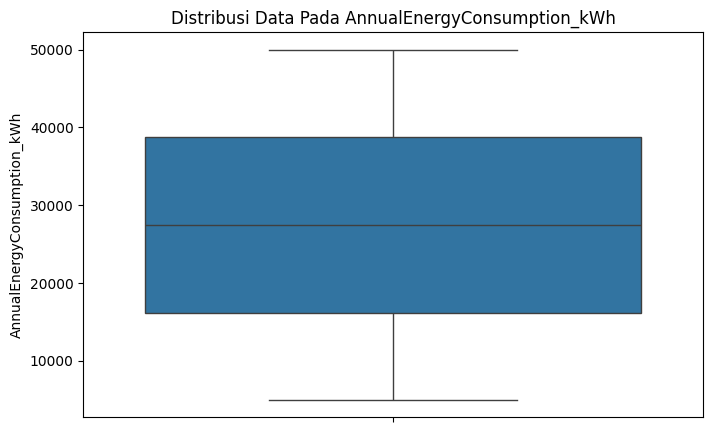

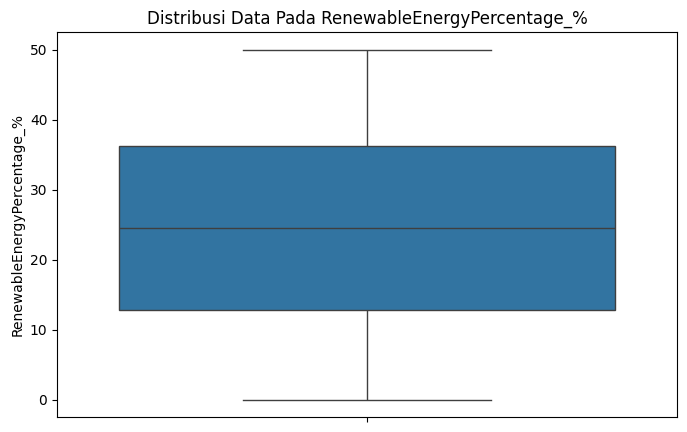

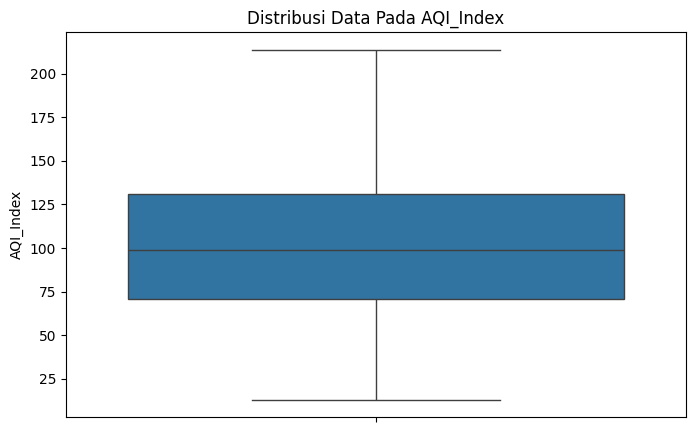

In [53]:
for column in air_df:
    boxplot_handler(air_df[column], f"Distribusi Data Pada {column}")

##### Feature Importance and Correlation

In [54]:
X_adf = air_df.drop(columns = ["AQI_Index"])
y_adf = air_df["AQI_Index"]

In [55]:
X_scaled_adf = scaler.fit_transform(X_adf)

In [56]:
rfr = RandomForestRegressor()

In [57]:
rfr.fit(X_scaled_adf, y_adf)

RandomForestRegressor()

In [58]:
feature_importance = pd.DataFrame({
    "Feature": X_adf.columns,
    "Importance": rfr.feature_importances_
}).sort_values(by = "Importance", ascending = False)

feature_importance

,Feature,Importance
0,PM2.5,0.671803
1,PM10,0.268400
2,O3,0.043348
3,NO2,0.010032
5,SO2,0.001543
6,AnnualEnergySavings_%,0.001450
4,CO,0.001445
8,RenewableEnergyPercentage_%,0.001226
7,AnnualEnergyConsumption_kWh,0.000751


In [97]:
air_df.corr()

,PM2.5,PM10,O3,NO2,CO,SO2,AnnualEnergySavings_%,AnnualEnergyConsumption_kWh,RenewableEnergyPercentage_%,AQI_Index
PM2.5,1.000000,0.122629,0.098732,0.170681,0.173685,0.179131,-0.049076,-0.011160,-0.060909,0.815688
PM10,0.122629,1.000000,0.086798,0.138667,0.138314,0.144705,-0.057614,-0.025168,-0.055174,0.617469
O3,0.098732,0.086798,1.000000,0.103039,0.121130,0.121480,-0.005690,0.007699,-0.004845,0.336063
NO2,0.170681,0.138667,0.103039,1.000000,0.168335,0.198398,-0.028560,-0.018804,-0.023349,0.327369
CO,0.173685,0.138314,0.121130,0.168335,1.000000,0.197512,0.010208,-0.006110,0.009206,0.275483
SO2,0.179131,0.144705,0.121480,0.198398,0.197512,1.000000,0.000667,-0.007701,-0.007793,0.285972
AnnualEnergySavings_%,-0.049076,-0.057614,-0.005690,-0.028560,0.010208,0.000667,1.000000,0.018342,0.728180,-0.066512
AnnualEnergyConsumption_kWh,-0.011160,-0.025168,0.007699,-0.018804,-0.006110,-0.007701,0.018342,1.000000,0.012613,-0.021060
RenewableEnergyPercentage_%,-0.060909,-0.055174,-0.004845,-0.023349,0.009206,-0.007793,0.728180,0.012613,1.000000,-0.073285
AQI_Index,0.815688,0.617469,0.336063,0.327369,0.275483,0.285972,-0.066512,-0.021060,-0.073285,1.000000


### Insights

- Teknologi penghematan energi berpengaruh terhadap penghematan energi. Adapun urutan teknologi dengan rata-rata persentase penghematan energi tertinggi yaitu
    - Smart Thermostats
    - Insulation
    - LED Lighting
    - Efficient HVAC
    - Solar Panels
- Jumlah kontribusi energi terbarukan sangat berpengaruh terhadap penghematan energi. Hal ini dapat dilihat dari feature importance tertinggi sebesar 0.66.
- Penghematan energi dan penggunaan energi terbarukan berpengaruh terhadap indeks kualitas udara (AQI). Hal ini dapat dilihat dari feature importance yang tertinggi setelah polutan. 
- Penggunaan energi terbarukan memiliki korelasi negatif terhadap AQI. Hal ini menunjukkan semakin besar penggunaan energi terbarukan, semakin kecil nilai AQI. Oleh karena itu, semakin besar penggunaan energi terbarukan, semakin baik kualitas udara. Begitu pula dengan sebaliknya.
- Adapun kadar polutan yang paling terpengaruh karena adanya penggunaan energi ialah PM2.5. 

# Building Dataset

### Data Processing

In [59]:
building_df = pd.read_csv("building_dataset.csv")

In [60]:
building_df.head(5)

,BuildingID,BuildingType,YearBuilt,MonthlyElectricityConsumption_kWh,PeakUsageTime_Hour,RenewableCapacity_kWh,RenewableType,RenewableContributionPercentage,EnergySource,EnergyEfficiency_kWh_per_m2,WeatherData_Temperature_C,WeatherData_SolarIntensity_Hours,WeatherData_WindSpeed_km_h
0,B000001,Educational,NaN,673.62,8,3292.66,NaN,30.27,Electricity,21.15,12.51,5.44,71.64
1,B000002,Agricultural,NaN,294.60,10,0.00,Tidal,0.00,Coal,21.01,18.22,8.91,10.85
2,B000003,Retail,2020.0,210.20,20,6483.89,Solar,90.72,Electricity,34.53,39.40,3.59,13.45
3,B000004,Commercial,NaN,174.14,5,12150.11,Wind,45.16,Biomass,48.66,17.97,3.65,40.85
4,B000005,Educational,NaN,61.27,23,3516.48,Solar,96.59,Electricity,25.46,16.18,8.11,72.20


In [61]:
building_df.drop(columns = ["BuildingID"], inplace = True)

##### Handling Missing Values

In [62]:
building_df.isna().sum()

BuildingType                            0
YearBuilt                            7219
MonthlyElectricityConsumption_kWh       0
PeakUsageTime_Hour                      0
RenewableCapacity_kWh                   0
RenewableType                         568
RenewableContributionPercentage       654
EnergySource                            0
EnergyEfficiency_kWh_per_m2             0
WeatherData_Temperature_C               0
WeatherData_SolarIntensity_Hours        0
WeatherData_WindSpeed_km_h            317
dtype: int64

In [63]:
building_df.drop(columns = ["YearBuilt"], inplace = True)

In [64]:
groupby_building_type_df = building_df.groupby(by = ["BuildingType"]).agg({
    "RenewableType": lambda x: x.mode().iloc[0],
    "RenewableContributionPercentage": "median",
    "WeatherData_WindSpeed_km_h": "median"
})

groupby_building_type_df

,RenewableType,RenewableContributionPercentage,WeatherData_WindSpeed_km_h
BuildingType,,,
Agricultural,Solar,63.010,58.015
Commercial,Solar,62.070,58.935
Educational,Solar,60.720,57.355
Government,Solar,61.860,59.015
Healthcare,Solar,60.030,59.935
Hospitality,Solar,63.050,59.630
Industrial,Solar,61.100,60.730
Recreational,Solar,63.280,61.490
Religious,Solar,62.175,53.905


In [65]:
groupby_building_type_df.reset_index(inplace = True)

building_df = pd.merge(building_df, groupby_building_type_df, how = "left", on = "BuildingType", suffixes = ["", "_agg"])

columns_to_fill = ["RenewableType", "RenewableContributionPercentage", "WeatherData_WindSpeed_km_h"]
for column in columns_to_fill:
    building_df[column].fillna(building_df[f"{column}_agg"], inplace = True)
    building_df.drop(columns = [f"{column}_agg"], inplace = True)

C:\Users\PC\AppData\Local\Temp\ipykernel_19100\1931318562.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  building_df[column].fillna(building_df[f"{column}_agg"], inplace = True)
C:\Users\PC\AppData\Local\Temp\ipykernel_19100\1931318562.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

##### Handling Duplicate Values

In [66]:
building_df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)

##### Building Type

In [67]:
groupby_building_type_df = building_df.groupby(by = ["BuildingType"]).agg({
    "EnergyEfficiency_kWh_per_m2": "mean",
    "RenewableContributionPercentage": "mean"
}).sort_values(by = "EnergyEfficiency_kWh_per_m2", ascending = False)

groupby_building_type_df

,EnergyEfficiency_kWh_per_m2,RenewableContributionPercentage
BuildingType,,
Religious,29.100669,61.202435
Retail,28.779341,59.873610
Recreational,28.632222,61.528444
Hospitality,28.426962,63.635886
Commercial,27.996180,61.077891
Government,27.970399,59.929601
Industrial,27.873239,60.719098
Sports,27.724688,60.846771
Agricultural,27.697485,60.381557


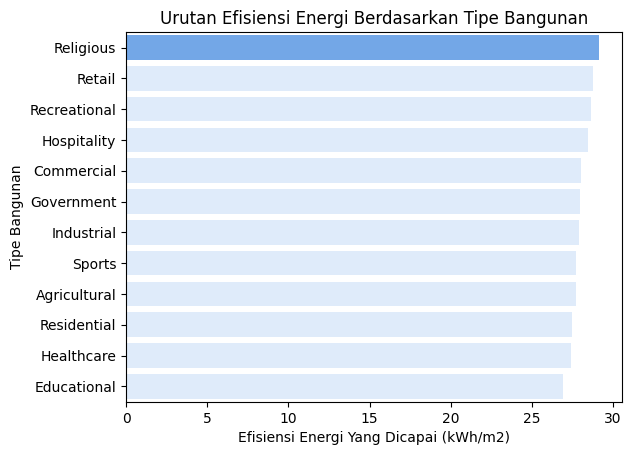

In [71]:
barplot_handler(
    groupby_building_type_df, 
    "BuildingType", 
    "EnergyEfficiency_kWh_per_m2",
    "Urutan Efisiensi Energi Berdasarkan Tipe Bangunan", 
    "Efisiensi Energi Yang Dicapai (kWh/m2)", 
    "Tipe Bangunan"
)

##### Renewable Type

In [72]:
groupby_renewable_type_df = building_df.groupby(by = ["RenewableType"]).agg({
    "EnergyEfficiency_kWh_per_m2": "mean",
}).sort_values(by = "EnergyEfficiency_kWh_per_m2", ascending = False)

groupby_renewable_type_df

,EnergyEfficiency_kWh_per_m2
RenewableType,
Biomass,28.608083
Geothermal,28.150648
Wind,27.952139
Hydro,27.843064
Solar,27.401107
Tidal,25.352952


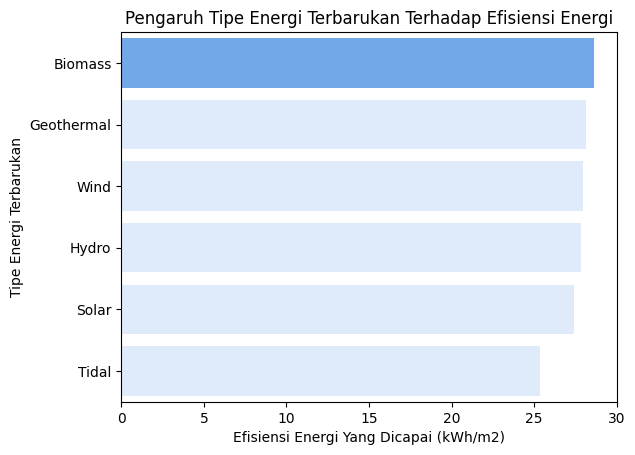

In [74]:
barplot_handler(
    groupby_renewable_type_df,
    "RenewableType",
    "EnergyEfficiency_kWh_per_m2",
    "Pengaruh Tipe Energi Terbarukan Terhadap Efisiensi Energi",
    "Efisiensi Energi Yang Dicapai (kWh/m2)",
    "Tipe Energi Terbarukan",
)

##### Energy Source

In [75]:
groupby_energy_source_df = building_df.groupby(by = ["EnergySource"]).agg({
    "EnergyEfficiency_kWh_per_m2": "mean",
}).sort_values(by = "EnergyEfficiency_kWh_per_m2", ascending = False)

groupby_energy_source_df

,EnergyEfficiency_kWh_per_m2
EnergySource,
Biomass,28.038593
Electricity,27.694587
Mixed Sources,27.679754
Natural Gas,27.173721
Coal,25.729423
Oil,24.327632
Nuclear,23.780833


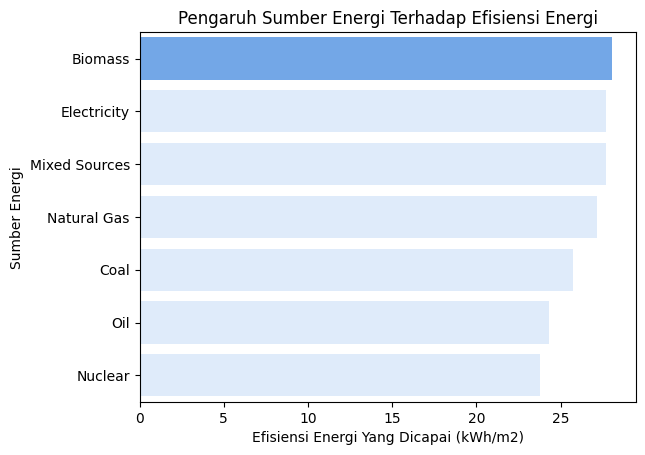

In [77]:
barplot_handler(
    groupby_energy_source_df,
    "EnergySource",
    "EnergyEfficiency_kWh_per_m2",
    "Pengaruh Sumber Energi Terhadap Efisiensi Energi",
    "Efisiensi Energi Yang Dicapai (kWh/m2)",
    "Sumber Energi"
)

##### Monthly Electrical Consumption

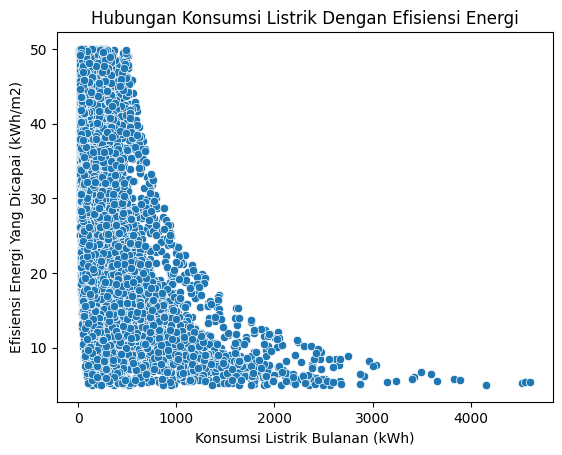

In [79]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "MonthlyElectricityConsumption_kWh",
    "Hubungan Konsumsi Listrik Dengan Efisiensi Energi",
    "Konsumsi Listrik Bulanan (kWh)",
    "Efisiensi Energi Yang Dicapai (kWh/m2)",
)

##### Peak Usage Time

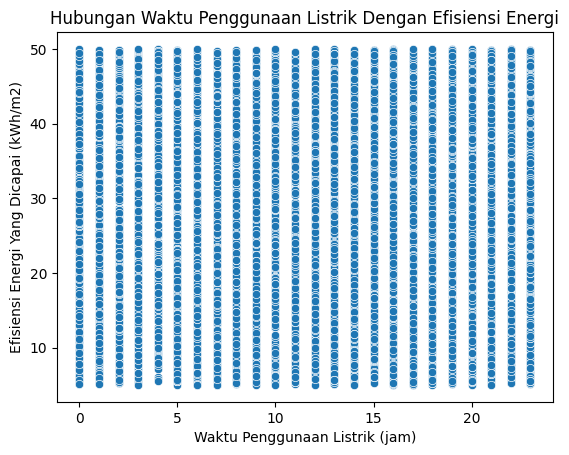

In [80]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "PeakUsageTime_Hour",
    "Hubungan Waktu Penggunaan Listrik Dengan Efisiensi Energi",
    "Waktu Penggunaan Listrik (jam)",
    "Efisiensi Energi Yang Dicapai (kWh/m2)",
)

##### Renewable Contribution Percentage

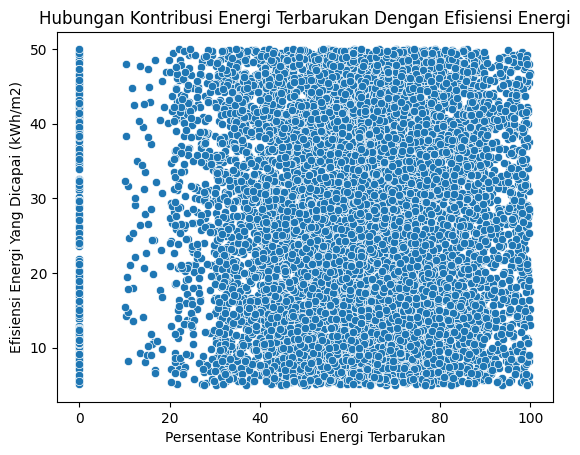

In [81]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "RenewableContributionPercentage",
    "Hubungan Kontribusi Energi Terbarukan Dengan Efisiensi Energi",
    "Persentase Kontribusi Energi Terbarukan",
    "Efisiensi Energi Yang Dicapai (kWh/m2)"
)

##### Weather Data (Temperature)

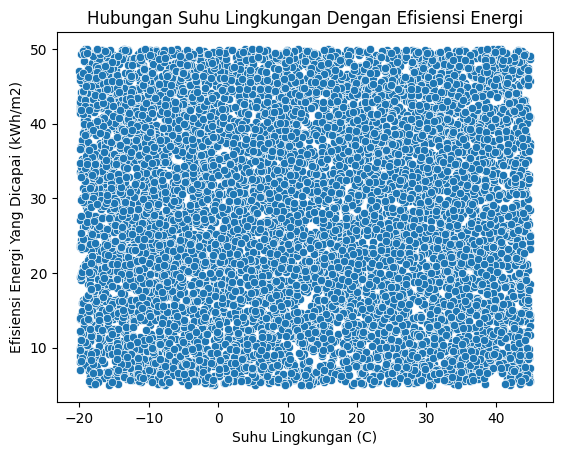

In [82]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "WeatherData_Temperature_C",
    "Hubungan Suhu Lingkungan Dengan Efisiensi Energi",
    "Suhu Lingkungan (C)",
    "Efisiensi Energi Yang Dicapai (kWh/m2)"
)

##### Weather Data (Solar Intensity)

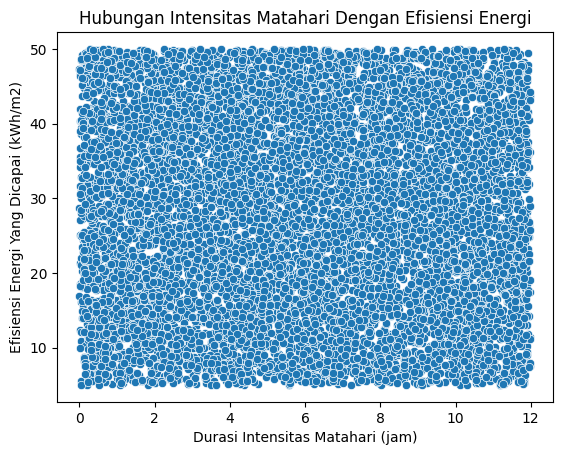

In [83]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "WeatherData_SolarIntensity_Hours",
    "Hubungan Intensitas Matahari Dengan Efisiensi Energi",
    "Durasi Intensitas Matahari (jam)",
    "Efisiensi Energi Yang Dicapai (kWh/m2)",
)

##### Weather Data (Wind Speed)

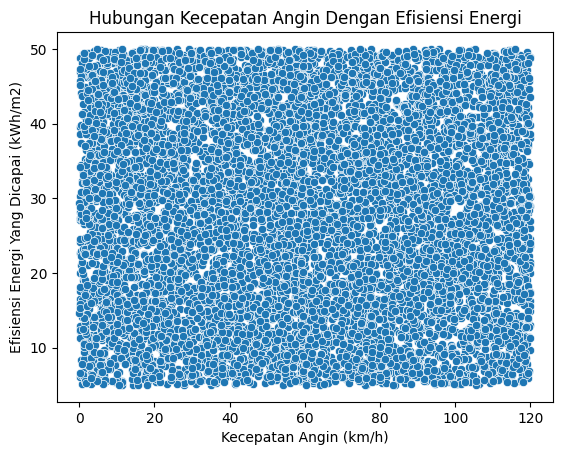

In [84]:
scatterplot_handler(
    building_df,
    "EnergyEfficiency_kWh_per_m2",
    "WeatherData_WindSpeed_km_h",
    "Hubungan Kecepatan Angin Dengan Efisiensi Energi",
    "Kecepatan Angin (km/h)",
    "Efisiensi Energi Yang Dicapai (kWh/m2)"
)

##### Handle Outliers

In [85]:
building_df = building_df[[
    "BuildingType",
    "MonthlyElectricityConsumption_kWh",
    "PeakUsageTime_Hour",
    "RenewableType",
    "RenewableContributionPercentage",
    "EnergySource",
    "WeatherData_Temperature_C",
    "WeatherData_SolarIntensity_Hours",
    "WeatherData_WindSpeed_km_h",
    "EnergyEfficiency_kWh_per_m2"
]]

In [86]:
building_df_categorical_columns = ["BuildingType", "RenewableType", "EnergySource"]

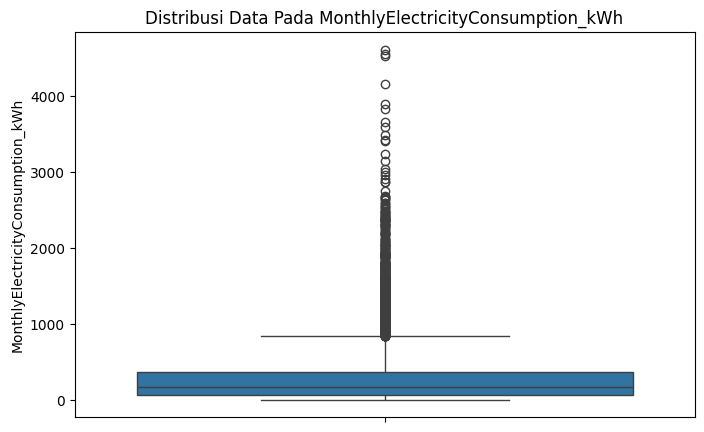

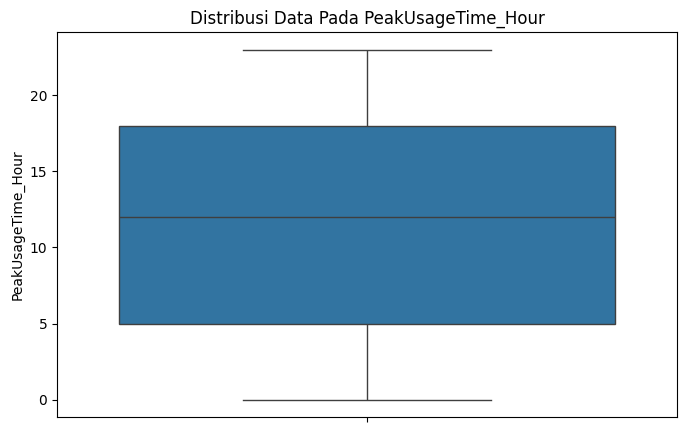

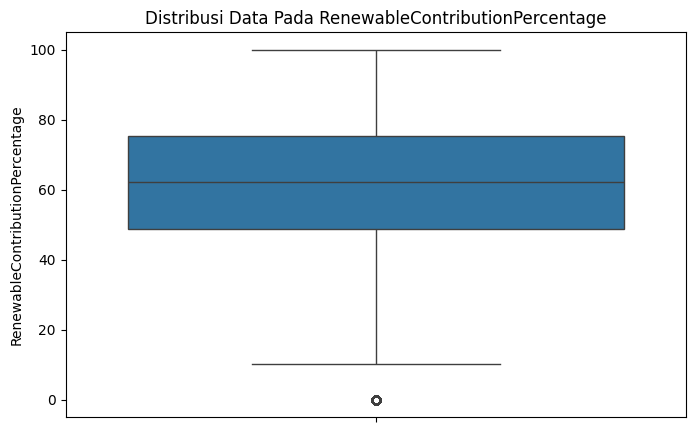

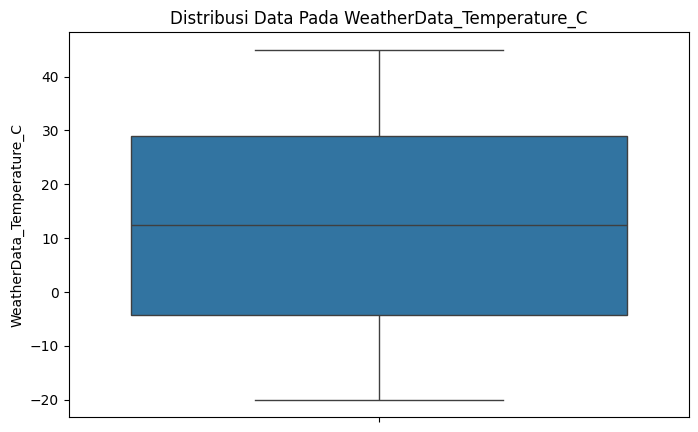

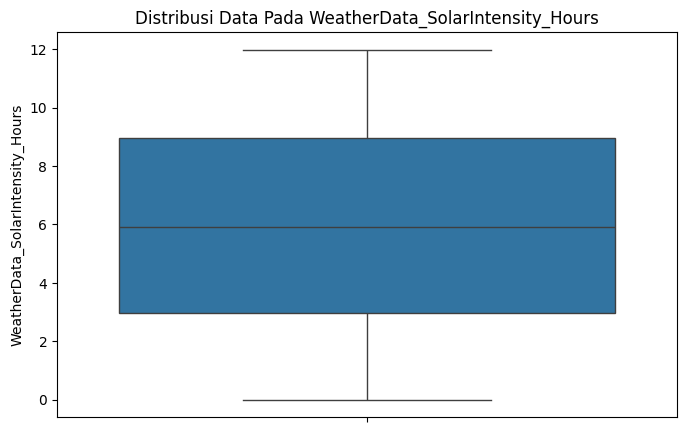

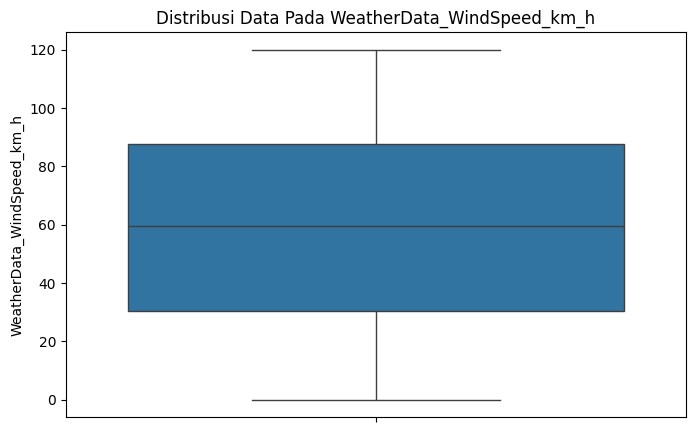

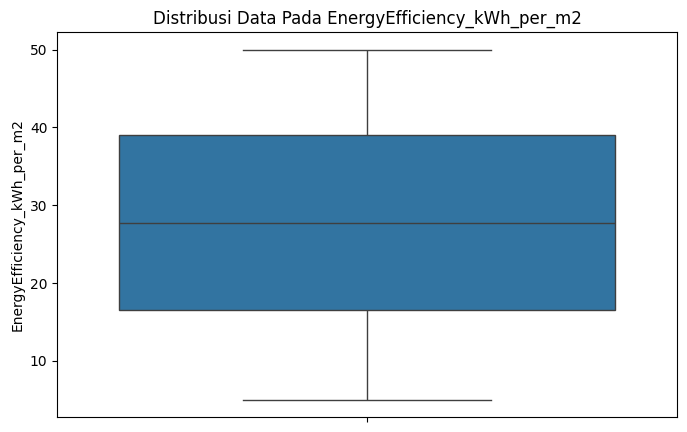

In [87]:
building_df_numerical_columns = []
for column in building_df.columns:
    if column not in building_df_categorical_columns:
        building_df_numerical_columns.append(column)
        boxplot_handler(building_df[column], f"Distribusi Data Pada {column}")

In [88]:
building_df = remove_outliers_handler(building_df, "MonthlyElectricityConsumption_kWh")
building_df = remove_outliers_handler(building_df, "RenewableContributionPercentage")

##### Feature Importance and Correlation

In [89]:
scaler = StandardScaler()

In [90]:
for column in building_df_categorical_columns:
    if column in building_df.columns:
        building_df[column] = building_df[column].astype("category").cat.codes

In [91]:
X_bdf = building_df.drop(columns = ["EnergyEfficiency_kWh_per_m2"])
y_bdf = building_df["EnergyEfficiency_kWh_per_m2"]

In [92]:
X_scaled_bdf = scaler.fit_transform(X_bdf)

In [93]:
rfr = RandomForestRegressor()

In [94]:
rfr.fit(X_scaled_bdf, y_bdf)

RandomForestRegressor()

In [95]:
feature_importance = pd.DataFrame({
    "Feature": X_bdf.columns,
    "Importance": rfr.feature_importances_
}).sort_values(by = "Importance", ascending = False)

feature_importance

,Feature,Importance
1,MonthlyElectricityConsumption_kWh,0.387076
0,BuildingType,0.200535
8,WeatherData_WindSpeed_km_h,0.083284
6,WeatherData_Temperature_C,0.081166
7,WeatherData_SolarIntensity_Hours,0.079533
4,RenewableContributionPercentage,0.078516
2,PeakUsageTime_Hour,0.055102
3,RenewableType,0.020395
5,EnergySource,0.014393


In [96]:
building_df.corr()

,BuildingType,MonthlyElectricityConsumption_kWh,PeakUsageTime_Hour,RenewableType,RenewableContributionPercentage,EnergySource,WeatherData_Temperature_C,WeatherData_SolarIntensity_Hours,WeatherData_WindSpeed_km_h,EnergyEfficiency_kWh_per_m2
BuildingType,1.000000,-0.388614,0.009914,0.006009,0.017878,0.006894,-0.006399,0.015986,0.009006,-0.059570
MonthlyElectricityConsumption_kWh,-0.388614,1.000000,0.001550,-0.016925,-0.012358,-0.011547,-0.013252,-0.003039,0.000929,-0.334931
PeakUsageTime_Hour,0.009914,0.001550,1.000000,-0.019471,0.010691,0.005928,0.013519,0.006746,-0.011289,-0.001294
RenewableType,0.006009,-0.016925,-0.019471,1.000000,0.236431,0.025128,-0.007084,0.023286,-0.008321,-0.001812
RenewableContributionPercentage,0.017878,-0.012358,0.010691,0.236431,1.000000,0.008472,-0.014066,-0.007344,-0.016451,-0.003550
EnergySource,0.006894,-0.011547,0.005928,0.025128,0.008472,1.000000,0.012094,0.004371,0.007560,-0.011653
WeatherData_Temperature_C,-0.006399,-0.013252,0.013519,-0.007084,-0.014066,0.012094,1.000000,-0.017105,0.009737,0.012755
WeatherData_SolarIntensity_Hours,0.015986,-0.003039,0.006746,0.023286,-0.007344,0.004371,-0.017105,1.000000,-0.000357,-0.009591
WeatherData_WindSpeed_km_h,0.009006,0.000929,-0.011289,-0.008321,-0.016451,0.007560,0.009737,-0.000357,1.000000,-0.015106
EnergyEfficiency_kWh_per_m2,-0.059570,-0.334931,-0.001294,-0.001812,-0.003550,-0.011653,0.012755,-0.009591,-0.015106,1.000000


### Insights

- Tipe bangunan berpengaruh terhadap efisiensi energi. Adapun urutan tipe bangunan dengan rata-rata efisiensi energi tertinggi yaitu:
    - Religious
    - Retail
    - Recreational
    - Hospitality
    - Commercial
    - Government
    - Industrial
    - Sports
    - Agricultural
    - Residential
    - Healthcare
    - Educational
- Jumlah kontribusi energi terbarukan pada bangunan mempengaruhi efisiensi energi. Hal ini dapat dilihat dari bangunan religious yang memiliki kontribusi sebesar 61.20%, berbanding terbalik dengan bangunan healthcare yang hanya memiliki kontribusi sebesar 59.01%.
- Tipe energi terbarukan berpengaruh terhadap efisiensi energi. Adapun urutan tipe energi terbarukan dengan rata-rata efisiensi energi tertinggi yaitu:
    - Biomass
    - Geothermal
    - Wild
    - Hydro
    - Solar
    - Tidal
- Sumber energi utama bangunan berpengaruh terhadap efisiensi energi. Adapun urutan sumber energi utama dengan rata-rata efisiensi energi tertinggi yaitu:
    - Biomass
    - Electricity
    - Mixed Sources
    - Natural Gas
    - Coal
    - Oil
    - Nuclear